# Semantic Features in Statistical Workflows — Tutorial

**Public Sector Responsible AI Hackathon | Databricks × RSS AI Task Force × Manuka | 9 July 2026**

---

## What this notebook is

This notebook is a **worked example** of the first two stages of a possible pipeline for statistical modelling wth semantic features:  data ingestion and feature engineering. The other stages of the pipeline are more standard statistics/data science project stages where the semantic features are taken as inputs.
We will take the time to work through this notebook on the first day of the hackathon,
and you may subsequently use it as a reference during team working time.

The dataset used here is the **20 Newsgroups** corpus — a classic collection
of ~18,000 news articles across 20 topic categories, pre-loaded on every
Databricks workspace at `/databricks-datasets/news20.binary/`. It has no
connection to the hackathon use cases, but its structure — unstructured text
that needs to be turned into something a model can act on — is exactly the
same problem you will face on the day.



## Where the AI Principles fit into the Pipeline

**The UK Government AI Principles**

We have already had an introduction to these in the presentations, but as a reminder, here are the ten principles for responsible AI use in public sector organisations.  

- P1:  **You know what AI is and what its limitations are**:  AI is not a single technology, and AI technologies are evolving rapidly.  While it is useful to understand in theory how AI technologies work, the best way to really understand the strengths ad limitations of AI tools is to experiment and evaluate the suitability of tools in low-risk settings that model the sort of work you wish to use it for before embedding them in your work.  This hackathon is just such a setting, so by participating, you are already making progress towards the first principle.  More broadly, we encourage you to keep experimenting as the technology evolves.  Hackathons can be a fun way to do this, so we hope you will enjoy this one as well as learn from it!

- P2: **You use AI lawfully, ethically and responsibly**:  The basic requirements around lawful, ethical and responsible use of _data_ hold in all statistical workflows, and AI workflows are no different.  The main differences coming from AI tools as opposed to more conventional statistical and data tooling are 
    1. When we use an LLM, we do not control the underpinning model we are using, and the models commonly used are regularly updated by the companies that provide them.  This means that more needs to be done to evaluate the performance of the model against a clear set of suitability criteria and on a representative test set of cases both when initially undertaking work, and also in ongoing monitoring of tools built on top of them.    
    2. LLMs are both financially and environmentally costly to use.  So when designing workflows using calls, work to optimise your workflows to reduce these costs, through model selection, prompt optimisation and efficient architectures.  Databricks has several models available, and you will have the opportunity to compare how these perform to identify the most efficient one to use for your use case.

- P3: **You know how to use AI securely**:  Because data flows to models and responses back from models, it is important to to work with LLM models and AI tools built on these that have been approved by your organisation for the use case and data you have in mind.  Cybersecurity is a complex field of its own, and it is not possible to undertake adequate security evaluation as an individual statistician.  In this hackathon, as we are not working within the service boundary of your organisation, it is consequently important only to use publicly available data.  

- P4:  **You have meaningful human control at the right stages** In any project, it is essential to identify the risk level of the use case you are building towards, and understand any legal or departmental governance standards around which decisions or validations must sit with human experts and which may be taken by a system.  In this tutorial, the use case is low-risk, and consequently, our human control is aimed at sense checking and ensuring explainability.

- P5: **You understand how to manage the full AI life cycle** For any data project, it is necessary to monitor suitability and performance of a tool as the data it is built on may evolve.  Given point 1 of principle 2, when the tool is build using a foundation LLM, it is additionally necessary to monitor the suitability and performance of the underpinning model throughout the project life cycle.

- P6: **You use the right tool for the job** Different AI and statistical tools are good at different things.  In this hackathon, you will combine an LLM tool to extract semantic features from unstructured text--a job that LLMs are good at.  You will then construct a model using these features and conventional statistical or ml techniques--something LLMs are NOT good at, and where other techniques are both more effective and less costly.

- P7: **You are open and collaborative** In this hackathon, you will get to know colleagues from several different public sector agencies.  We hope you will take this opportunity to build a community for knowledge sharing with other public sector statisticians.  Additionally, we will show how to ensure that the datasets you create for analysis are discoverable and understandable by other users.

- P8: **You work with commercial colleagues from the start** Manuka has talked about how to identify suitable use cases for AI models.  A tool may perform extremely well according to a set of evaluation metrics, but still not meet the requirements of the end users.  The best tool is the one that performs best in the setting in which it will be used.  So think carefully about how the tool you will develop in the hackathon will deliver value, and what it needs to provide in order for the intended users to get benefit from it.

- P9: **You have the skills and expertise needed to implement and use AI solutions**  The skills and experience you develop in this hackathon will complement the statistical skills you already have, and will also give you ideas of new tools to try out and sample data to try them on in the future.

- P10: **You use these principles alongside your organisation's policies and have the right assurance in place** In this hackathon, we encourage you to use the policies in your organsation to determine the appropriate risk level and required assurance for your project.  If your organisation has not yet provided assurance guidelines for AI projects, we encourage you to consider the framework set out in the EU AI Act.



**A seven-stage pipeline for statistical modelling with LLM-derived semantic features**

| Stage | What happens | Playbook principles |
|-------|-------------|---------------------|
| 1 — Ingest | Load, examine and clean raw data and save as a Delta Table | P2, P4, P7, P10 |
| 2 — Feature Engineering | Generate quantitative and categorical features to feed downstream models| P1, P6, P9 |
| 3 — Human Review | Route feature outputs to a domain expert for sense checking before use | P4, P8 |
| 4 — Model | Train and evaluate model; log with MLflow; explain with SHAP or other tools | P1, P5, P7 |
| 6 — Surface Outputs for Users | Create a dashboard or app to permit business users to engage with the outputs of your model | P6, P8  |
| 7 — Govern | Audit trail, lineage, monitoring | P5, P10 |


## Configuration and Package Loading

In [0]:
import re
import os
from datetime import datetime, UTC
from typing import Optional
import json

import pandas as pd
import numpy as np

from pyspark.sql import functions as F, types as T
from pyspark.sql.window import Window
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType, DoubleType, ArrayType, FloatType, BooleanType
)

from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml.feature import Normalizer
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

import matplotlib.pyplot as plt
import seaborn as sns


# ── Unity Catalog target ──────────────────────────────────────────────────────
UC_CATALOG = "hackathon"
UC_SCHEMA = "default"
USERNAME = "tutorial" # Provide a unique tag to label your data assets

# ── Table names ───────────────────────────────────────────────────────────────
PROCESSED_TABLE = f"{UC_CATALOG}.{UC_SCHEMA}.tutorial_sci_med_posts_{USERNAME}"
SUMMARISED_TABLE = f"{UC_CATALOG}.{UC_SCHEMA}.tutorial_sci_med_summarised_{USERNAME}"
VECTORISED_TABLE = f"{UC_CATALOG}.{UC_SCHEMA}.tutorial_sci_med_vectorised_{USERNAME}"
CLASSIFIED_TABLE = f"{UC_CATALOG}.{UC_SCHEMA}.tutorial_sci_med_classified_{USERNAME}"
FEATURES_TABLE = f"{UC_CATALOG}.{UC_SCHEMA}.tutorial_sci_med_features_{USERNAME}"
AUTO_POST_FEATURES_TABLE = f"{UC_CATALOG}.{UC_SCHEMA}.tutorial_sci_med_auto_post_features_{USERNAME}"
REVIEW_TABLE = f"{UC_CATALOG}.{UC_SCHEMA}.tutorial_sci_med_for_review_{USERNAME}"

# ── Sample size ───────────────────────────────────────────────────────────────
# Keep at 200 for the tutorial to limit AI Function token consumption.
# Increase for your use case work.
SAMPLE_SIZE = 200

# ── MLflow experiment ─────────────────────────────────────────────────────────
EXPERIMENT_NAME = f"/Users/{USERNAME}/hackathon_tutorial"

print(f"UC target: {UC_CATALOG}.{UC_SCHEMA}")
print(f"Sample size: {SAMPLE_SIZE} articles")

UC target: hackathon.default
Sample size: 200 articles


## 1. Ingest through an ETL pipeline

### What we are doing and why

The first stage of every pipeline is getting your raw data into **Delta Lake**
under Unity Catalog governance, having embedded data protection in the assets and having provided metadata. This matters for four reasons that map
directly to the AI Playbook:

- **Principle 2:** You need to know the data you are working with and determine if there are any special legal considerations for working with it.  Is the data sensitive?  Is there personal data?  What limitations or biases may the data have that will need to be balanced for in modelling or limit the situations in which the tool can suitably be used.
- **Principle 4:** Starting out with a manual investigation of the data provides human control at the very start of the process, and permits first considerations of tooling costs.
- **Principle 7:** By providing metadata when saving tables, it is possible for other users to discover and understand the datasets you create and how they were generated.
- **Principle 10:** Unity Catalog records who created each table, when, and from what source and tracks the lineage of data assets.  This is the first stage in assurance and audit of AI systems.

### About the 20 Newsgroups dataset

The 20 Newsgroups dataset contains articles from 20 newsgroups with broad categories, indicated by the field "topic".  We will work with the topic sci.space, but you can explore some of the other topics if you like at the end of the tutorial.
Each file is a raw email/newsgroup post, and the raw text has several pieces of information in headers.  So the first thing we need to do is extract relevant header data into separate fields both so that we can examine that data separately and potentially use these fields in our models, but also so that the main messages do not have headers, which may otherwise trigger spurious labels.

**This is the same operation you will perform in your use case** — the CQC
corpus, for example, arrives as JSON with a `report_text` field. It may make sense to split the text into sections before analysing, etc.  

In [0]:
spark.read.parquet("/databricks-datasets/news20.binary/data-001/training").groupBy('topic').count().display()

topic,count
misc.forsale,585
rec.sport.hockey,600
talk.politics.guns,546
comp.sys.mac.hardware,578
talk.politics.misc,465
comp.sys.ibm.pc.hardware,590
comp.windows.x,593
sci.crypt,595
alt.atheism,480
soc.religion.christian,599


In [0]:
raw_df = spark.read.parquet("/databricks-datasets/news20.binary/data-001/training").filter(F.col('topic').isin(['talk.religion.misc','rec.autos','sci.space'])).drop('label')
display(raw_df.limit(20))

id text topic 84263 From: bcash@crchh410.NoSubdomain.NoDomain (Brian Cash) Subject: Re: Are atoms real? (was Re: After 2000 years blah blah blah) Nntp-Posting-Host: crchh410 Organization: BNR, Inc. Lines: 15 Petri and Mathew, Your discusion on the "reality" of atoms is interesting, but it would seem that you are verging on the question "Is anything real": that is, since observation is not 100% reliable, how can we say that anything is "real". I don't think this was the intention of the original question, since you now define-out the word "real" so that nothing can meet its criteria. Just a thought. Brian /-|-\ PS Rainbows and Shadows are "real": they are not objects, they are phenomenon. An interesting question would be if atoms are objects (classical) or phenomenon (neo-quantum) or what? talk.religion.misc 61163 From: nsmca@aurora.alaska.edu Subject: Space Design Movies? Article-I.D.: aurora.1993Apr23.124722.1 Organization: University of Alaska Fairbanks Lines: 11 Nntp-Posting-Host: acad3.alaska.edu Is there a few Grasp pictures of space related items, namely Space Station Designs, so you can see the "finished" revolt around.. If you don't know what a grasp prograsm is.. Check out some adult entertainment files and see what I mean.. Or maybe geta few GIF files and create a "slide shows" (I think Cshow can do this).. I liek to be able to see a space shuttle design in a AutoCAD program or to see it revolt around and look at it. == Michael Adams, nsmca@acad3.alaska.edu -- I'm not high, just jacked sci.space 103169 From: aas7@po.CWRU.Edu (Andrew A. Spencer) Subject: Re: Dumb options list Organization: Case Western Reserve University, Cleveland, OH (USA) Lines: 21 Reply-To: aas7@po.CWRU.Edu (Andrew A. Spencer) NNTP-Posting-Host: slc5.ins.cwru.edu In a previous article, parr@acs.ucalgary.ca (Charles Parr) says: >The idea here is to list pointless options. You know, stuff you >(can) get on a car that has no earthly use? 1) a fitting that allows you to generate household current with the engine running, and plug ins in the trunk, engine compartment and cabin. Feel free to add on... Regards, Charles x -- Within the span of the last few weeks I have heard elements of separate threads which, in that they have been conjoined in time, struck together to form a new chord within my hollow and echoing gourd. --Unknown net.person :-) rec.autos 60160 From: yamauchi@ces.cwru.edu (Brian Yamauchi) Subject: Griffin / Office of Exploration: RIP Organization: Case Western Reserve University Lines: 19 Distribution: world NNTP-Posting-Host: yuggoth.ces.cwru.edu Any comments on the absorbtion of the Office of Exploration into the Office of Space Sciences and the reassignment of Griffin to the "Chief Engineer" position? Is this just a meaningless administrative shuffle, or does this bode ill for SEI? In my opinion, this seems like a Bad Thing, at least on the surface. Griffin seemed to be someone who was actually interested in getting things done, and who was willing to look an innovative approaches to getting things done faster, better, and cheaper. It's unclear to me whether he will be able to do this at his new position. Does anyone know what his new duties will be? -- _______________________________________________________________________________ Brian Yamauchi Case Western Reserve University yamauchi@alpha.ces.cwru.edu Department of Computer Engineering and Science _______________________________________________________________________________ sci.space 60213 From: thomsonal@cpva.saic.com Subject: Cosmos 2238: an EORSAT Article-I.D.: cpva.15337.2bc16ada Organization: Science Applications Int'l Corp./San Diego Lines: 48 >Date: Tue, 6 Apr 1993 15:40:47 GMT >I need as much information about Cosmos 2238 and its rocket fragment (1993- >018B) as possible. Both its purpose, launch date, location, in short, >EVERYTHING! Can you help? >-Tony Ryan, "Astronomy & Space", new International magazine, available from: ----------------------------------------------

In [0]:
KNOWN_HEADERS = [
    "From", "Subject", "Organization", "Lines", "Distribution",
    "Reply-To", "NNTP-Posting-Host", "Nntp-Posting-Host", "Article-I.D.",
    "X-Added", "Original-Sender", "Newsgroups", "Path", "Message-ID",
    "References", "Date", "Sender", "Followup-To", "Keywords",
    "Summary", "Expires", "X-Newsreader", "In-Reply-To", "Approved","News-Software",
    "Supersedes", "X-Last-Updated","X-X-From",
]
# Longest first so e.g. "NNTP-Posting-Host" matches before any shorter prefix could
_sorted_headers = sorted(set(KNOWN_HEADERS), key=len, reverse=True)
HEADER_KEY_RE = re.compile(
    r'(?:^|(?<=\s))(' + '|'.join(re.escape(h) for h in _sorted_headers) + r'):\s'
)

HEADER_SCHEMA = StructType([
    StructField("from_email", StringType(), True),
    StructField("from_name", StringType(), True),
    StructField("subject", StringType(), True),
    StructField("organization", StringType(), True),
    StructField("lines_header", StringType(), True),
    StructField("distribution", StringType(), True),
    StructField("reply_to", StringType(), True),
    StructField("nntp_posting_host", StringType(), True),
    StructField("body", StringType(), True),
])

FROM_RE = re.compile(r'^(\S+)(?:\s*\((.*)\))?\s*$')

def parse_post(content):
    if content is None:
        return (None, None, None, None, None, None, None, None, "")

    # Body boundary: the flattened blank line shows up as 2+ spaces
    parts = re.split(r'\s{2,}', content, maxsplit=1)
    header_block = parts[0]
    body = parts[1].strip() if len(parts) > 1 else ""

    matches = list(HEADER_KEY_RE.finditer(header_block))
    headers = {}
    for i, m in enumerate(matches):
        key = m.group(1).strip().lower()
        start = m.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(header_block)
        headers[key] = header_block[start:end].strip()

    from_raw = headers.get("from")
    from_email, from_name = None, None
    if from_raw:
        m = FROM_RE.match(from_raw)
        from_email = m.group(1) if m else from_raw
        from_name = m.group(2) if m else None

    return (
        from_email, from_name,
        headers.get("subject"),
        headers.get("organization"),
        headers.get("lines"),
        headers.get("distribution"),
        headers.get("reply-to"),
        headers.get("nntp-posting-host"),
        body,
    )

parse_post_udf = F.udf(parse_post, HEADER_SCHEMA)

In [0]:
processed_df = (
    raw_df
    .withColumnRenamed("id", "article_id")
    .withColumn("parsed", parse_post_udf(F.col("text")))
    
    .select(
        "article_id",
        "topic",
        F.col("parsed.subject").alias("subject"),
        F.col("parsed.organization").alias("organization"),
        F.col("parsed.lines_header").alias("lines_header"),
        F.col("parsed.distribution").alias("distribution"),
        F.col("parsed.body").alias("text"),
    )
    .withColumn("char_count", F.length("text"))
    .withColumn("word_count", F.size(F.split(F.trim(F.col("text")), r"\s+")))
    .filter(F.col("word_count")>30)
)

print(f"Rows after cleaning: {processed_df.count()}")
display(processed_df.limit(10))

Rows after cleaning: 1524


article_id topic subject organization lines_header distribution text char_count word_count 84263 talk.religion.misc Re: Are atoms real? (was Re: After 2000 years blah blah blah) BNR, Inc. 15 null Petri and Mathew, Your discusion on the "reality" of atoms is interesting, but it would seem that you are verging on the question "Is anything real": that is, since observation is not 100% reliable, how can we say that anything is "real". I don't think this was the intention of the original question, since you now define-out the word "real" so that nothing can meet its criteria. Just a thought. Brian /-|-\ PS Rainbows and Shadows are "real": they are not objects, they are phenomenon. An interesting question would be if atoms are objects (classical) or phenomenon (neo-quantum) or what? 597 100 61163 sci.space Space Design Movies? University of Alaska Fairbanks 11 null Is there a few Grasp pictures of space related items, namely Space Station Designs, so you can see the "finished" revolt around.. If you don't know what a grasp prograsm is.. Check out some adult entertainment files and see what I mean.. Or maybe geta few GIF files and create a "slide shows" (I think Cshow can do this).. I liek to be able to see a space shuttle design in a AutoCAD program or to see it revolt around and look at it. == Michael Adams, nsmca@acad3.alaska.edu -- I'm not high, just jacked 507 94 103169 rec.autos Re: Dumb options list Case Western Reserve University, Cleveland, OH (USA) 21 null In a previous article, parr@acs.ucalgary.ca (Charles Parr) says: >The idea here is to list pointless options. You know, stuff you >(can) get on a car that has no earthly use? 1) a fitting that allows you to generate household current with the engine running, and plug ins in the trunk, engine compartment and cabin. Feel free to add on... Regards, Charles x -- Within the span of the last few weeks I have heard elements of separate threads which, in that they have been conjoined in time, struck together to form a new chord within my hollow and echoing gourd. --Unknown net.person :-) 592 103 60160 sci.space Griffin / Office of Exploration: RIP Case Western Reserve University 19 world Any comments on the absorbtion of the Office of Exploration into the Office of Space Sciences and the reassignment of Griffin to the "Chief Engineer" position? Is this just a meaningless administrative shuffle, or does this bode ill for SEI? In my opinion, this seems like a Bad Thing, at least on the surface. Griffin seemed to be someone who was actually interested in getting things done, and who was willing to look an innovative approaches to getting things done faster, better, and cheaper. It's unclear to me whether he will be able to do this at his new position. Does anyone know what his new duties will be? -- _______________________________________________________________________________ Brian Yamauchi Case Western Reserve University yamauchi@alpha.ces.cwru.edu Department of Computer Engineering and Science _______________________________________________________________________________ 909 125 60213 sci.space Cosmos 2238: an EORSAT Science Applications Int'l Corp./San Diego 48 null >Date: Tue, 6 Apr 1993 15:40:47 GMT >I need as much information about Cosmos 2238 and its rocket fragment (1993- >018B) as possible. Both its purpose, launch date, location, in short, >EVERYTHING! Can you help? >-Tony Ryan, "Astronomy & Space", new International magazine, available from: ------------------------------------------------------------------------------ Ocean Reconnaissance Launch Surprises West Space News, April 5-11, 1993, p.2 [Excerpts] Russia launched its first ocean reconnaissance satellite in 26 months March 30, confounding Western analysts who had proclaimed the program dead. The Itar-TASS news agency announced the launch of Cosmos 2238 from Plesetsk Cosmodrome, but provided little description of the payload's mission. However, based on the satellite's trajectory, Western observers identified it 

### Cap the working set before paying for LLM calls

Every downstream step in this notebook — `ai_mask`, `ai_summarize`, the embedding
call and the two `ai_query` classifications — sends text to a model and is billed by
the token. That means **cost scales directly with the number of rows.** Before running
any of them, we cap the dataset to `SAMPLE_SIZE` rows (set in the config cell at the
top). Work out your approach and validate quality on this small, cheap sample first;
only scale up once you are happy. This is Principle 2 (use AI responsibly and keep
costs down) and Principle 4 (meaningful human control early) in practice.

In [0]:
# limit() gives an exact, cheap cap; ordering first makes the sample reproducible across runs.
full_row_count = processed_df.count()
processed_df = processed_df.orderBy("article_id").limit(SAMPLE_SIZE)
print(f"Working on {processed_df.count()} of {full_row_count} rows (SAMPLE_SIZE={SAMPLE_SIZE}).")

Working on 200 of 1524 rows (SAMPLE_SIZE=200).


### Getting a feel for tooling costs

Before spending anything, get a feel for the shape of your data. Next to where it says
**Table** in a display above, click the **+** icon and select **Data Profile**. This
gives summaries of missingness, most common values, and average field lengths. You will
notice, for example, that `distribution` is ~80% missing (so unlikely to be a useful
feature), while `topic`, `subject` and `text` are complete.

A common rule of thumb for English text is **~4 characters per token**. The next cell
turns that into a rough-order-of-magnitude (ROM) cost estimate. The key points it makes:

- Cost is driven by **tokens × passes × rate**. This notebook makes *several* LLM passes
  over the data (two `ai_mask` calls, `ai_summarize`, an embedding, and `ai_query` for
  tension and car extraction), so you multiply, not add once.
- **Output tokens** cost money too, and are often priced higher than input tokens.
- **Prompt caching** reduces the input cost of the shared prompt prefix. Databricks AI
  Functions cache the common prefix automatically, and some served models bill cached
  reads at a reduced rate — so the ROM figure is an upper bound on the input side.

In [0]:
# Rule of thumb: ~4 characters per token for English text.
CHARS_PER_TOKEN = 4

# $ per 1M tokens. THESE ARE PLACEHOLDERS — set them from the current Databricks pricing
# page for your chosen model, or derive them from system.billing.list_prices (next section).
# Foundation Model APIs are billed in DBUs; convert the DBU price to $ via list_prices.
RATE_PER_M_INPUT = 0.50    # $/1M input tokens
RATE_PER_M_OUTPUT = 1.50   # $/1M output tokens

avg_text_chars = processed_df.agg(F.avg("char_count")).collect()[0][0] or 0
avg_subject_chars = processed_df.agg(F.avg(F.length("subject"))).collect()[0][0] or 0
sample_rows = processed_df.count()

text_tokens_in = avg_text_chars / CHARS_PER_TOKEN
subject_tokens_in = avg_subject_chars / CHARS_PER_TOKEN

# Every LLM pass this notebook makes, with rough input/output tokens PER ROW.
# Output sizes are estimates — a summary or JSON blob is far smaller than the input, but not free.
passes = [
    # name,                    input_tokens_per_row,     output_tokens_per_row
    ("ai_mask (text)",         text_tokens_in,           text_tokens_in),   # returns masked text ~ same size
    ("ai_mask (subject)",      subject_tokens_in,        subject_tokens_in),
    ("ai_summarize",           text_tokens_in,           60),               # ~50-word summary
    ("embedding (summary)",    60,                       0),                # embeddings billed on input only
    ("ai_query tension",       text_tokens_in + 120,     40),               # + prompt, small JSON out
    ("ai_query car (subset)",  text_tokens_in + 300,     80),               # rec.autos only, so over-counts here
]

print(f"{'pass':<24}{'in tok/row':>12}{'out tok/row':>13}")
total_in = total_out = 0.0
for name, tin, tout in passes:
    total_in += tin
    total_out += tout
    print(f"{name:<24}{tin:>12,.0f}{tout:>13,.0f}")

def rom_cost(rows):
    c_in = rows * total_in / 1e6 * RATE_PER_M_INPUT
    c_out = rows * total_out / 1e6 * RATE_PER_M_OUTPUT
    return c_in + c_out

print(f"\nPer row: {total_in:,.0f} input + {total_out:,.0f} output tokens across all passes")
print(f"Est. cost on sample     ({sample_rows} rows): ${rom_cost(sample_rows):,.4f}")
print(f"Est. cost on full corpus ({full_row_count} rows): ${rom_cost(full_row_count):,.2f}")
print("\nROM figures only. Prompt caching and cached-token discounts reduce the input side.")

pass                      in tok/row  out tok/row
ai_mask (text)                   375          375
ai_mask (subject)                  8            8
ai_summarize                     375           60
embedding (summary)               60            0
ai_query tension                 495           40
ai_query car (subset)            675           80

Per row: 1,990 input + 564 output tokens across all passes
Est. cost on sample     (200 rows): $0.3680
Est. cost on full corpus (1524 rows): $2.80

ROM figures only. Prompt caching and cached-token discounts reduce the input side.


### Measuring what a run *actually* cost, with system tables

The estimate above is a planning tool. To see what a run really cost, query the billing
**system tables** after it finishes. `system.billing.usage` records every billable event;
`system.billing.list_prices` gives the price per unit so you can turn DBUs into dollars.

Foundation Model API / Model Serving and AI Functions usage appear under
`billing_origin_product` values `MODEL_SERVING` and `AI_FUNCTIONS`; the specific function
is in `product_features.ai_functions.ai_function` and the endpoint in
`usage_metadata.endpoint_name`. **Caveat:** these records land with a few hours' latency,
so run the next cell later, not immediately after the cells above. This is the audit and
lifecycle-monitoring evidence called for by Principles 5 and 10.

In [0]:
spark.sql("""
WITH ai_usage AS (
  SELECT
    u.sku_name,
    u.billing_origin_product,
    u.usage_metadata.endpoint_name                 AS endpoint_name,
    u.product_features.ai_functions.ai_function    AS ai_function,
    u.usage_unit,
    SUM(u.usage_quantity)                          AS usage_quantity
  FROM system.billing.usage u
  WHERE u.billing_origin_product IN ('MODEL_SERVING', 'AI_FUNCTIONS')
    AND u.usage_date >= current_date() - INTERVAL 2 DAYS
    -- Optional: narrow to this notebook only
    -- AND u.usage_metadata.notebook_path = '<your notebook path>'
  GROUP BY ALL
)
SELECT
  a.billing_origin_product,
  a.endpoint_name,
  a.ai_function,
  a.sku_name,
  a.usage_unit,
  a.usage_quantity,
  p.pricing.effective_list.default                                 AS unit_price_usd,
  ROUND(a.usage_quantity * p.pricing.effective_list.default, 4)    AS est_cost_usd
FROM ai_usage a
LEFT JOIN system.billing.list_prices p
  ON a.sku_name = p.sku_name
  AND p.price_end_time IS NULL          -- current price
ORDER BY est_cost_usd DESC
""").display()

billing_origin_product,endpoint_name,ai_function,sku_name,usage_unit,usage_quantity,unit_price_usd,est_cost_usd


### GDPR Considerations

Notice that this dataset contains personal data, in particular PII data, in the form of names, email addresses and institutions, as well as text written by identifiable natural persons in the 1990s.  Because the data is in newsgroups related to religion, it is also possible that it will contain sensitive data related to religion or beliefs of the poster or another identifiable individual.  This means that the data is protected by GDPR.  Therefore:

- **We should apply appropriate anonymisation/pseudonimisation prior to processing according to the standards set by our organisation**:  in the cleaning step, we therefore need code that will allow us to strip names and email addresses from the data.
- **We need a legal basis for processing the data**.  Because this is a publicly available dataset that has been widely used for research, and because we are using this for training and the outputs of our work will not feed into any decision making process, we can take Legitimate Interests as our legal basis for processing.

Removal of email addresses and phone numbers is fairly straightforward with regex, but it is much trickier to identify names to redact.  This is a nice use for ai tooling, such as the ai_mask function available in Databricks.  Similar functions can be created outside of Databricks by having an LLM identify all names in a text field, then using a replace to redact.  Note this isn't perfect, so where risk level on the project is high, additional methods should be used.


In [0]:
BARE_HOST_EMAIL_PATTERN = r'\b[\w.+-]+@[\w-]+\b'
EMAIL_PATTERN = r'[\w.+-]+@[\w-]+\.[\w.-]+'
UUCP_PATTERN = r'\bUUCP:\s*\S+'
PHONE_PATTERN = r'\+?\d[\d\-\s]{6,}\d'


def redact_structured(df, text_col="text"):
    return (
        df
        .withColumn(text_col, F.regexp_replace(F.col(text_col), EMAIL_PATTERN, "[EMAIL]"))
        .withColumn(text_col, F.regexp_replace(F.col(text_col), BARE_HOST_EMAIL_PATTERN, "[EMAIL]"))
        .withColumn(text_col, F.regexp_replace(F.col(text_col), UUCP_PATTERN, "[UUCP_ID]"))
        .withColumn(text_col, F.regexp_replace(F.col(text_col), PHONE_PATTERN, "[PHONE]"))
    )

redacted_df = (
    processed_df
    .withColumn("text", F.expr("ai_mask(CAST(text AS STRING), array('person', 'email'))"))
    .withColumn("subject", F.expr("ai_mask(CAST(subject AS STRING), array('person', 'email'))"))
)
redacted_df = redact_structured(redacted_df,text_col="text")
redacted_df = redact_structured(redacted_df,text_col="subject")


display(redacted_df)

article_id,topic,subject,organization,lines_header,distribution,text,char_count,word_count
101551,rec.autos,Re: Saturn's Pricing Policy,Brown Computer Science Dept.,51,null,"In article <[MASKED]>, [MASKED] ([MASKED]) writes: |> [MASKED] ([MASKED]) wrote: |> : I have been active in defending Saturn lately on the net and would |> : like to state my full opinion on the subject, rather than just reply to others' |> : points. |> : |> : The biggest problem some people seem to be having is that Saturn |> : Dealers make ~$2K on a car. I think most will agree with me that the car is |> : comparably priced with its competitors, that is, they aren't overpriced |> : compared to most cars in their class. I don't understand the point of |> : arguing over whether the dealer makes the $2K or not? |> |> I have never understood what the big deal over dealer profits is either. |> The only thing that I can figure out is that people believe that if |> they minimize the dealer profit they will minimize their total out-of-pocket |> expenses for the car. While this may be true in some cases, I do not |> believe that it is generally true. I bought a Saturn SL in January of '92. |> AT THAT TIME, based on studying car prices, I decided that there was |> no comparable car that was priced as cheaply as the Saturn. Sure, maybe I |> could have talked the price for some other car to the Saturn price, but |> my out-of-pocket expenses wouldn't have been any different. What's important |> to me is how much money I have left after I buy the car. REDUCING DEALER PROFIT |> IS NOT THE SAME THING AS SAVING MONEY! Show me how reducing dealer profit |> saves me money, and I'll believe that it's important. My experience has |> been that reducing dealer profit does not necessarily save me money. |> |> [MASKED] Say, you bought your Saturn at $13k, with a dealer profit of $2k. If the dealer profit is $1000, then you would only be paying $12k for the same car. So isn't that saving money? Moreover, if Saturn really does reduce the dealer profit margin by $1000, then their cars will be even better deals. Say, if the price of a Saturn was already $1000 below market average for the class of cars, then after they reduce the dealer profit, it would be $2000 below market average. It will: 1) Attract even more people to buy Saturns because it would SAVE THEM MONEY. 2) Force the competitors to lower their prices to survive. Now, not only will Saturn owners benefit from a lower dealer profit, even the buyers for other cars will pay less. Isn't that saving money? $0.02, [MASKED].",2471,450
101552,rec.autos,Re: Are BMW's worth the price?,null,null,null,"Organization: DSG, Stanford University, CA 94305, USA Lines: 19 In article <[EMAIL]> [MASKED] ([MASKED]) writes: >Road and Track (2/88) BMW325is 0-60 7.5s, 1/4 mile 15.7s > (Road Test > Annual 1993) 0-60 8.3s, 1/4 mile 16.2s > > >Those are the numbers I was quoting, I have driven the older model but not the >newer. sure sounds like they got a ringer. the 325is i drove was definitely faster than that. if you want to quote numbers, my AW AutoFile shows 0-60 in 7.4, 1/4 mile in 15.9. it quotes Car and Driver's figures of 6.9 and 15.3. oh, BTW, these numbers are for the 325i. i don't know how the addition of variable valve timing for 1993 affects it. but don't take my word for it. go drive it. -[MASKED]",802,133
101553,rec.autos,RE: headlights problem,"Tektronix Inc., Beaverton, Or.",6,null,"THANKS TO ALL OF YOU WHO RESPONDED TO MY POSTING. THE PROBLEM WITH MY TRUCK'S HEADLIGHTS LOW BEAM PROBLEM WAS A ""LOOSE WIRE CONNECTION"". IT WAS NOT THE ""FUSE"" AS A MINORITY OF YOU SUGGESTED. THANKS AGAIN.",209,37
101554,rec.autos,left turn signal won't stop automaticaly,"Tektronix Inc., Beaverton, Or.",5,null,The subject says it all. My 1984 Chev S10 Pickup's left turn signal does not stop after turning. What cause this to stop automaticaly?. Is this a mechanical problem by the steering wheel?. NOTE: This truck has an after market steering wheel (G

### Masking strategies: who sees the raw data, and when?

We redacted PII **in memory, before the first table write** — so raw personal data never
lands in a governed table. That is one valid strategy, but not the only one. Which you
choose depends on your risk level and on who genuinely needs access to the raw data.

| Strategy | How it works | Trade-off | Who can see raw |
|---|---|---|---|
| **A. Redact at source** (this notebook) | Mask before writing any table; raw never persists | Simplest and safest, but you cannot re-derive if masking was too aggressive | Only the ingest job / its owner |
| **B. Tiered medallion** | Bronze = raw (locked down), Silver = masked, Gold = aggregated | Raw stays available for re-processing, but Bronze must be locked down hard | A small DE / DPO group, on Bronze only |
| **C. Dynamic masking** | One table; Unity Catalog **column masks** + **row filters** reveal raw only to a privileged group | Flexible, single source of truth, but needs careful group management | Members of a privileged UC group |

**Persona guidance.** Raw PII should reach only a Data Protection / data-engineering group.
Model builders and analysts should work from the masked Silver layer; business users should
only ever see aggregated Gold outputs or a dashboard. Note that `ai_mask` **itself** sends
raw text to the model endpoint, so the masking step must run under the privileged persona —
masking is a way to avoid *persisting or exposing* raw data, not a way to avoid *processing*
it. (Principles 2, 3 and 4.)

In [0]:
# This shows how you would expose one table to two personas. It needs a real UC group,
# so it is left here as a string to read rather than run.
COLUMN_MASK_EXAMPLE = """
-- 1. A mask function: the privileged group sees the value, everyone else a placeholder.
CREATE OR REPLACE FUNCTION hackathon.default.mask_pii(val STRING)
RETURN CASE
  WHEN is_account_group_member('data_protection_officers') THEN val
  ELSE '[REDACTED]'
END;

-- 2. Apply it to a column holding raw text on the (locked-down) raw table.
ALTER TABLE hackathon.default.raw_posts
  ALTER COLUMN text SET MASK hackathon.default.mask_pii;

-- 3. Optionally, a ROW FILTER to hide whole rows from non-privileged users:
--    CREATE FUNCTION ... RETURN is_account_group_member(...);
--    ALTER TABLE ... SET ROW FILTER ...;
"""
print(COLUMN_MASK_EXAMPLE)


-- 1. A mask function: the privileged group sees the value, everyone else a placeholder.
CREATE OR REPLACE FUNCTION hackathon.default.mask_pii(val STRING)
RETURN CASE
  WHEN is_account_group_member('data_protection_officers') THEN val
  ELSE '[REDACTED]'
END;

-- 2. Apply it to a column holding raw text on the (locked-down) raw table.
ALTER TABLE hackathon.default.raw_posts
  ALTER COLUMN text SET MASK hackathon.default.mask_pii;

-- 3. Optionally, a ROW FILTER to hide whole rows from non-privileged users:
--    CREATE FUNCTION ... RETURN is_account_group_member(...);
--    ALTER TABLE ... SET ROW FILTER ...;



### Add metadata

In [0]:
# Column metadata (name, type, comment) for Unity Catalog
column_metadata = [
    ("article_id",        "STRING",  "Unique identifier from the source dataset"),
    ("topic",             "STRING",  "Newsgroup topic label (filtered to talk.religion.misc, rec.autos, sci.space)"),
    ("subject",           "STRING",  "Subject line of the original post with emails and names redacted"),
    ("organization",      "STRING",  "Organization header, self-reported by the poster"),
    ("lines_header",      "STRING",  "Line count as given by the header"),
    ("distribution",      "STRING",  "Distribution header, where present"),
    ("text",              "STRING",  "Article body with headers stripped and emails and names redacted"),
    ("char_count",        "INT",     "Character count of the stripped body text"),
    ("word_count",        "INT",     "Word count of the stripped body text"),
]

# Cast columns to explicit types (Spark Connect compatible - no .rdd access needed)
processed_df_with_comments = redacted_df.select(
    F.col("article_id").cast("string"),
    F.col("topic").cast("string"),
    F.col("subject").cast("string"),
    F.col("organization").cast("string"),
    F.col("lines_header").cast("string"),
    F.col("distribution").cast("string"),
    F.col("text").cast("string"),
    F.col("char_count").cast("int"),
    F.col("word_count").cast("int")
)

# Ensure schema exists before writing table
spark.sql(f"CREATE CATALOG IF NOT EXISTS {UC_CATALOG}")
spark.sql(f"CREATE SCHEMA IF NOT EXISTS {UC_CATALOG}.{UC_SCHEMA}")

# Write table
(
    processed_df_with_comments.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(PROCESSED_TABLE)
)

# Apply column comments via ALTER TABLE (Spark Connect compatible)
for col_name, col_type, col_comment in column_metadata:
    spark.sql(f"""
        ALTER TABLE {PROCESSED_TABLE}
        ALTER COLUMN `{col_name}` COMMENT '{col_comment.replace("'", "\\'")}';
    """)

In [0]:
spark.sql(f"""
    COMMENT ON TABLE {PROCESSED_TABLE} IS
    'Posts from three newsgroups (talk.religion.misc, rec.autos, sci.space) from the news20 public training dataset of newsgroup posts, available at https://www.cs.cmu.edu/afs/cs.cmu.edu/project/theo-20/www/data/news20.html.  Names and email addresses have been redacted using the ai_mask function and regex.'
""")

DataFrame[]

In [0]:
# ── Provenance metadata ───────────────────────────────────────────────────────
PROCESSED_BY = spark.sql("SELECT current_user()").collect()[0][0]

try:
    NOTEBOOK_PATH = (
        dbutils.notebook.entry_point.getDbutils().notebook()
        .getContext().notebookPath().get()
    )
except Exception as exc:
    NOTEBOOK_PATH = None
    print("Could not determine notebook path: %s", exc)

spark.sql(f"""
    ALTER TABLE {PROCESSED_TABLE} SET TBLPROPERTIES (
        'notebook_path' = '{NOTEBOOK_PATH}',
        'processed_by' = '{PROCESSED_BY}',
        'last_ingested_at' = '{datetime.now(UTC).isoformat()}'
    )
""")

DataFrame[]

In [0]:
text_dataset = spark.table(PROCESSED_TABLE)

Go to the Catalog in the menu column to the left of the screen and find the dataset you just saved.  You can look through the various tabs to find a range of information about the dataset, its lineage, when it was created, by whom, etc. as well as the metadata you have provided above.

## 2. Engineering Semantic Features

### What we are doing and why

Raw text is not useful for a statistical model on its own. We need to
**extract structured semantic features** from it — properties that can be
represented as columns in a table and used downstream.  This is one of the most powerful capabilities that LLMs provide, and opens up many new approaches for working statistically with unstructured text data.


### Principles we embed at this stage

**P1:  You know what AI is and what its limitations are**
Before running these functions, it is worth being explicit about what they
cannot do reliably:

- `ai_summarize` can drop important information. A summary is lossy by
  design. Do not use summaries as the sole input to downstream decisions.

- clustering on text embeddings may not create categories that are meaningful in your use-case.
This is why subject matter expert review is critical at this stage.
  
- `ai_query` is not adapted automatically to the context of your data and use-case, so it is useful to craft your prompt to include contextual clues and test its performance on a representative sample of data.

These limitations are not reasons to avoid LLM extraction — they are
reasons to test, validate, and build human review into your pipeline.

**P6: You use the right tool for the job**
Databricks provides several SQL AI Functions for working with free text. You can read about them here:
https://docs.databricks.com/aws/en/large-language-models/ai-functions

The dataset we are using provides text already in a field in a table.  But some of the datasets that have been provided for the hackathon were ingested originally as pdf files into a volume. You can see them in the catalog to the left (click on the icon of a triangle over a circle and a square under the folder icon in the Workspace panel).  Go to My organisation -> dbacademy -> hackathon -> shared_datasets -> Volumes -> cqc_safe_inadequate_reports to see these, one per folder with the cqc location id as a folder name.  When starting with raw documents, the ai_parse_document function can be used to initially extract text and formatting information from the files, which can then be passed to other ai functions.

In addition to the built-in databricks functions, it is also possible to call models directly.  You can experiment with this in the Playground, towards the bottom of the far left menu panel.  In this tutorial, we will use a text embedding model to convert text summaries into vectors we can use to examine semantic similarity.

We will use the following workflow to classify the subjects of the posts:
1. Summarise the post using ai_summarize function
2. Embed the summaries using a text embedding
3. Look for semantic clusters
4. Expert feedback

Then we will extract some additional structured fields using ai_query on the original text field, which model two different types of tasks that can be undertaken with this function:
1. Across the full dataset, we will identify the tone of the post: escalating, de-escalating, or neutral, together with a brief justification of the category.
2. For posts from the rec.autos newsgroup, we will extract two lists:  one of car models and makes mentioned, and one of automobile parts or features mentioned.


**P9:  You have the skills and expertise needed to implement and use AI solutions**  Make sure to explore these tools and test their capabilities before implementing them into your project pipeline.  You should be able to justify the choices you made through evidence you collected during this exploration stage.

### Features from semantic clusters

#### Step 1: One-sentence summary with `ai_summarize`

If you embed the full text and try to create clusters, the length and diversity of the text will have a tendency to create unclear clusters.  So as a pre-processing step, we use ai_summarize to extract the general topic of a post in a shorter phrase.

In [0]:
summarised_df = (
    text_dataset
    .filter(F.col('text').isNotNull())
    .withColumn("summary", F.expr("ai_summarize(text,50)"))
)
display(summarised_df)

article_id,topic,subject,organization,lines_header,distribution,text,char_count,word_count,summary
101551,rec.autos,Re: Saturn's Pricing Policy,Brown Computer Science Dept.,51,null,"In article <[MASKED]>, [MASKED] ([MASKED]) writes: |> [MASKED] ([MASKED]) wrote: |> : I have been active in defending Saturn lately on the net and would |> : like to state my full opinion on the subject, rather than just reply to others' |> : points. |> : |> : The biggest problem some people seem to be having is that Saturn |> : Dealers make ~$2K on a car. I think most will agree with me that the car is |> : comparably priced with its competitors, that is, they aren't overpriced |> : compared to most cars in their class. I don't understand the point of |> : arguing over whether the dealer makes the $2K or not? |> |> I have never understood what the big deal over dealer profits is either. |> The only thing that I can figure out is that people believe that if |> they minimize the dealer profit they will minimize their total out-of-pocket |> expenses for the car. While this may be true in some cases, I do not |> believe that it is generally true. I bought a Saturn SL in January of '92. |> AT THAT TIME, based on studying car prices, I decided that there was |> no comparable car that was priced as cheaply as the Saturn. Sure, maybe I |> could have talked the price for some other car to the Saturn price, but |> my out-of-pocket expenses wouldn't have been any different. What's important |> to me is how much money I have left after I buy the car. REDUCING DEALER PROFIT |> IS NOT THE SAME THING AS SAVING MONEY! Show me how reducing dealer profit |> saves me money, and I'll believe that it's important. My experience has |> been that reducing dealer profit does not necessarily save me money. |> |> [MASKED] Say, you bought your Saturn at $13k, with a dealer profit of $2k. If the dealer profit is $1000, then you would only be paying $12k for the same car. So isn't that saving money? Moreover, if Saturn really does reduce the dealer profit margin by $1000, then their cars will be even better deals. Say, if the price of a Saturn was already $1000 below market average for the class of cars, then after they reduce the dealer profit, it would be $2000 below market average. It will: 1) Attract even more people to buy Saturns because it would SAVE THEM MONEY. 2) Force the competitors to lower their prices to survive. Now, not only will Saturn owners benefit from a lower dealer profit, even the buyers for other cars will pay less. Isn't that saving money? $0.02, [MASKED].",2471,450,"Debater argues that reducing dealer profit doesn't necessarily save buyers money, but others counter that lower profits can lead to lower prices, benefiting consumers."
101552,rec.autos,Re: Are BMW's worth the price?,null,null,null,"Organization: DSG, Stanford University, CA 94305, USA Lines: 19 In article <[EMAIL]> [MASKED] ([MASKED]) writes: >Road and Track (2/88) BMW325is 0-60 7.5s, 1/4 mile 15.7s > (Road Test > Annual 1993) 0-60 8.3s, 1/4 mile 16.2s > > >Those are the numbers I was quoting, I have driven the older model but not the >newer. sure sounds like they got a ringer. the 325is i drove was definitely faster than that. if you want to quote numbers, my AW AutoFile shows 0-60 in 7.4, 1/4 mile in 15.9. it quotes Car and Driver's figures of 6.9 and 15.3. oh, BTW, these numbers are for the 325i. i don't know how the addition of variable valve timing for 1993 affects it. but don't take my word for it. go drive it. -[MASKED]",802,133,"BMW 325is acceleration times are discussed, with varying 0-60mph and 1/4 mile times quoted from different sources."
101553,rec.autos,RE: headlights problem,"Tektronix Inc., Beaverton, Or.",6,null,"THANKS TO ALL OF YOU WHO RESPONDED TO MY POSTING. THE PROBLEM WITH MY TRUCK'S HEADLIGHTS LOW BEAM PROBLEM WAS A ""LOOSE WIRE CONNECTION"". IT WAS NOT THE ""FUSE"" AS A MINORITY OF YOU SUGGESTED. THANKS AGAIN.",209,37,"Truck's low beam headlight issue resolved, ca

In [0]:
summarised_df.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable(SUMMARISED_TABLE)
summarised_df = spark.table(SUMMARISED_TABLE)  # read back — this "cuts" the lazy lineage here

#### Step 2: Text embedding

Next we convert the summarized text into **vector embeddings** — numerical representations that capture semantic meaning. Each summary becomes a point in high-dimensional space, where semantically similar texts are positioned closer together.

**Why embeddings?** Statistical clustering algorithms require numerical inputs. By embedding our text summaries, we can:
* Measure semantic similarity between posts using distance metrics (cosine similarity, Euclidean distance)
* Apply standard clustering algorithms like K-Means
* Discover thematic groups in the data without manual labeling

**The model:** We're using `databricks-qwen3-embedding-0-6b`, an efficient text embedding model from the Qwen3 family. This model balances quality and cost — it's faster and more economical than larger models while still capturing semantic relationships effectively for clustering tasks.

**Important:** Embedding models encode the meaning present in the text, but they don't understand your specific domain or use case. This is why expert review (Principle 4) is critical — the clusters we discover must make sense to subject matter experts, not just to the algorithm.

In [0]:
EMBEDDING_ENDPOINT = "databricks-qwen3-embedding-0-6b"  

embedded_df = (
    summarised_df  
    .withColumn(
        "embedding",
        F.expr(f"ai_query('{EMBEDDING_ENDPOINT}', summary)").cast(T.ArrayType(T.FloatType()))
    )
)

display(embedded_df.select("article_id", "summary", "embedding").limit(5))

article_id summary embedding 101551 Debater argues that reducing dealer profit doesn't necessarily save buyers money, but others counter that lower profits can lead to lower prices, benefiting consumers. List(0.011826102, -0.04143214, -0.011092069, 0.06818359, 0.011662983, -0.018595526, 0.022510374, -0.0068102037, -0.0044653732, 0.045346987, -0.011010509, -0.02047139, 0.03621234, -0.007992814, -0.025772747, 0.06883607, -0.030503187, -0.13049492, 0.021694781, 0.03768041, 0.013946645, -0.022673493, -0.09134644, 0.026751459, -0.042737085, -0.01565939, 0.07992814, 0.028056407, 0.02773017, -0.056439053, -0.039637834, -0.02544651, 0.0048935595, -0.0049955086, -0.0017943052, -0.014843797, 0.025609627, 0.045020748, -0.042737085, 0.01802461, 0.07862319, 0.015088475, -0.0068102037, -0.022347255, 0.042084612, -0.05546034, 0.110268205, -0.023652203, 0.06916231, 0.009950237, 0.0045265425, 0.0076665767, -0.014354441, -0.00603539, -0.013375729, -0.012641695, -0.014680679, 0.055134103, 0.0061985087, -0.022184137, -0.011418305, 0.011662983, -0.030503187, -0.029687595, -0.03735417, 0.07731824, 0.024304679, 0.02071607, -0.057417765, -0.011092069, -0.017779933, -0.02316285, -0.008278271, -0.017453695, 0.037191052, 0.04126902, -5.556229E-4, -0.026425222, 0.021857899, -0.020797627, 0.019900475, 0.12462265, 0.013131051, 0.0036905594, 3.0584747E-4, -0.010765831, -0.02055295, -0.017861493, 0.0026914577, -0.05807024, 0.014191323, 0.049914308, -0.053829156, -0.034744274, 0.0047508306, -0.0044857627, 0.05937519, 0.0024467797, -0.017535254, -0.0042818645, -0.03294997, -0.0070548817, -0.009583221, -0.0036905594, -0.018350849, 0.04469451, -0.055134103, 0.0, -0.025935866, 0.017861493, 0.0056683733, 0.010602713, -0.0655737, -0.001937034, 0.014680679, 0.034091797, 0.08808407, -0.03017695, 0.007014102, -0.009012305, -0.043389563, -0.018921763, -0.0043430342, -0.08547417, -0.016230306, 0.02903512, -0.019411119, 0.03246061, 0.014925357, -0.032134373, 0.0012488771, 0.024957154, 0.014599119, 0.057417765, 0.030013831, 8.0030086E-4, 0.01329417, 0.0077889157, -0.0027526272, -0.021531662, 0.031971257, 0.0018350849, -0.023978442, -0.026751459, -0.008237492, -2.7271398E-4, 0.007829695, 0.04926183, -0.022347255, 0.019411119, -0.021531662, -0.019248001, -0.0060761697, 0.0049751187, 0.030992543, 0.028872002, -0.007992814, 0.019411119, 0.013701967, 0.013620407, 0.0018656696, -0.019818917, 0.012560136, -0.02528339, 0.012560136, -0.0079520345, 0.001937034, -0.033928677, 0.038006645, 0.018432407, -0.04077966, 0.04143214, -0.012478577, 0.027567051, -0.0030380848, -0.03262373, -0.029361358, -0.019818917, -0.04077966, -0.033439323, -0.0041391356, -0.017535254, -0.033602443, -0.010072577, 0.013457289, -0.029687595, -0.009950237, -0.008726847, -0.0034254917, -0.0016617712, 0.012723255, -0.023652203, 0.03507051, 0.02283661, -0.046651933, -0.03507051, -0.008115153, -0.024467798, 0.020797627, -0.013131051, 0.0075442377, 0.05317668, 0.01329417, -0.03621234, -0.019737357, 0.044042036, 0.022347255, 0.0062392885, -0.013783526, -0.0029157458, -0.051219255, 0.045346987, -0.021042306, 0.023815323, -0.016719662, -0.013212611, 0.0054644747, 0.011826102, -0.0057091527, 0.024957154, 0.019982034, -0.017861493, -0.009134645, 0.007503458, 0.019818917, -0.010928949, -0.0048731696, -0.035559867, -0.030013831, -0.019166442, -0.025935866, -7.773623E-5, 0.009746339, -0.0035682204, 0.033276204, -0.0023754153, 0.034091797, 0.02773017, -0.0629638, 0.010317255, -0.019900475, 0.010113357, 0.020879187, 0.012315458, -0.04094278, 0.007829695, 0.012478577, -0.011499865, -0.01802461, 0.0066878647, -0.022184137, -0.02071607, -0.05415539, 0.033928677, -0.017045898, 0.0010194916, -0.007625797, 0.0033643222, -5.632691E-4, -0.008645289, -0.028056407, 0.0012947543, 0.011826102, 0.028708883, -0.046978172, 0.04567322, -0.0051586274, 0.028219527, -0.058722716, -0.010317255, -0.06850983, 0.012478577, -0.035396747, 0.0069733225, 0.010235695, 0.015251594, -0.0058314917, 0.074055865, 0.010521153, 0.039311595, 0.006891763, -0.0

In [0]:
to_vector_udf = F.udf(lambda arr: Vectors.dense(arr), VectorUDT())
vectorized_df = embedded_df.filter(F.col('text').isNotNull()).withColumn("features", to_vector_udf(F.col("embedding")))
normalizer = Normalizer(inputCol="features", outputCol="normalized_features", p=2.0)
vectorized_df = normalizer.transform(vectorized_df)

In [0]:
vectorized_df.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable(VECTORISED_TABLE)
vectorized_df = spark.table(VECTORISED_TABLE)  # read back — this "cuts" the lazy lineage here

#### Step 3: Cluster Analysis

We will use spherical k means for this clustering, which means it is clustering on cosine similarity, the standard similarity used for vector embedded text.  This is why we needed to normalise the vectors we obtained from the vector embedding.  This a bit of a quick first pass at assigning clusters that doesn't require installing any additional libraries.  It is enough to indicate if there is any discernable clustering going on, but in full workflows it will be necessary to evaluate different clustering methods to see what produces sensible clusters that make sense to your domain experts -- part of the human-in-the-loop called for by Principle 4 as well as choosing the correct tools, as in Principle 6.  


In [0]:
for k in range(2, 9):
    km = KMeans(featuresCol="features", predictionCol="cluster", k=k, seed=42)
    m = km.fit(vectorized_df)
    preds = m.transform(vectorized_df)
    evaluator = ClusteringEvaluator(featuresCol="features", predictionCol="cluster")
    score = evaluator.evaluate(preds)
    print(f"k={k}: silhouette={score:.4f}")

k=2: silhouette=0.0710
k=3: silhouette=0.0913
k=4: silhouette=0.0075
k=5: silhouette=0.0107
k=6: silhouette=0.0079
k=7: silhouette=-0.0176
k=8: silhouette=0.0195


**Interpreting the Results Above**

The silhouette scores measure cluster quality — how distinct and cohesive each cluster is. Higher scores (closer to 1.0) indicate tighter, more separated clusters. Our best score of ~0.09 at k=3 is modest, which tells us:

* The three newsgroups (religion, autos, space) do form somewhat distinct semantic clusters
* However, the clusters are not extremely tight — discussions within a newsgroup can wander across topics
* This is realistic: online discussions often digress or cross-reference other subjects

A perfect silhouette of 1.0 would mean every post is maximally similar to its cluster and maximally different from other clusters — rarely achieved with real conversational text.

**What This Tells Us**

Examining posts that fall into unexpected clusters (e.g., an autos post classified into the religion cluster) reveals:

* **Topic drift** — conversations that start on-topic but veer into other subjects
* **Cross-domain references** — analogies or comparisons between domains ("buying a car is an act of faith...")
* **Data quality issues** — misclassified posts, quotes from other threads, or generic replies

These outliers are valuable for quality assurance and for understanding the limitations of clustering — another reminder of **Principle 4: human review is essential**.

As we chose 3 different newsgroups, it is not surprising to find that three clusters is the best fit.  Note also that these are not very tight clusters -- the highest silouette is only 0.1244.  So we can see that the discussions in newsgroups can tend to wander.

In [0]:
K =3  
kmeans = KMeans(featuresCol="features", predictionCol="cluster", k=K, seed=42)
model = kmeans.fit(vectorized_df)
clustered_df = model.transform(vectorized_df)

display(clustered_df.crosstab('topic','cluster'))

topic_cluster,0,1,2
rec.autos,6,58,136


We can see from this that topic 0 is roughly religion, topic 1 is roughly space and topic 2 is roughly autos. 

It may be interesting to examine the posts that do not correspond to the expected cluster, as these are "outlying" posts in that newsgroup.

In [0]:
display(clustered_df
        .filter(F.col('topic')=='rec.autos')
        .filter(F.col('cluster')==0)
        )

article_id topic subject organization lines_header distribution text char_count word_count summary embedding features normalized_features cluster 101583 rec.autos Re: Did US drive on the left? HP Colorado Springs Division 4 null Left hand steering wheel placement was not standard until the 20's in the US. Driving on the right has been standard since standards came into being. Interestingly, Chrysler has just begun building right hand drive cars again for export to Japan. 246 41 Left-hand steering became standard in the US in the 1920s, while driving on the right has been standard, with Chrysler recently restarting right-hand drive car production for Japan export. List(-0.023332352, -0.009316155, -0.010239378, 0.040286075, -0.017876945, -0.028200252, 0.0446504, 0.032732435, -0.08258645, 0.04196466, -0.064122, 0.061100546, 0.050021876, -0.00990366, -0.046664704, 0.089972235, -0.052371897, -0.013764408, 0.050021876, 0.07285065, 0.079564996, -0.06512915, 0.0160305, 0.08258645, 0.047671854, 6.3733826E-4, -0.0037138725, 0.022660917, 0.0718435, -0.027360959, -0.0038607488, 0.10071518, -0.019975178, -0.008686685, 0.0074697095, -0.015526924, 0.0223252, -0.025682373, 0.004511201, -0.018128734, 0.013932267, -0.031389568, -0.05707194, 0.0019198832, -0.06311485, -0.0012117296, -0.0036299431, -0.04700042, -0.03373959, -0.011498317, -0.009022402, 0.026353806, 0.02585023, 0.021821624, -0.003944678, -0.0044902186, 1.9670934E-4, 0.024339503, 0.011246529, 0.004888883, 0.013848338, 0.03592175, -0.019975178, 0.07587211, 0.029375263, -0.0025808266, 0.013512621, -0.03373959, 0.02836811, 7.501183E-4, -2.085119E-4, 0.017876945, -0.011917964, -0.0041754837, -0.010994741, 0.011917964, 0.010575094, -0.07520067, -0.0076375683, 0.040286075, -0.019051956, 0.085943624, 0.035250314, 0.016282288, 0.0040286076, 0.09400084, 0.027193101, 0.016282288, -0.03709676, -0.03709676, 0.050021876, 0.020898402, 0.026353806, -0.053043332, 0.026689524, -0.04095751, -0.02836811, 0.0033361905, 0.009484014, -0.017121581, -0.016366217, -0.020898402, -0.015107278, 0.049014725, 0.09265797, 0.045657553, -0.057407655, 0.0128411865, -0.066472024, -0.0076795327, 0.034075305, 0.025514513, -0.010281342, -0.0015422013, -0.021485906, 0.012001893, 0.018968027, -0.042971812, 0.038775347, -0.032732435, -0.09870088, 0.043978963, -0.007301851, -0.011246529, -0.07520067, 0.0160305, -0.035586033, 0.0016890776, 0.009148296, 0.0040915543, 0.018884098, -9.2846813E-4, 0.020478755, -0.010575094, -0.0060848757, -0.025178796, -0.030046698, 0.031389568, 0.03709676, -0.028703827, 0.034075305, -0.036593184, -0.0018674274, -0.024339503, -0.016953724, -0.0030844025, -0.030214556, 0.020646613, 0.0043643247, 0.014687631, 0.007595604, -0.022493059, -0.047671854, -0.03860749, 0.017876945, 0.0039027135, 0.008225073, -0.019387674, 0.014351914, 0.008644721, 0.020394824, 0.002916544, 0.005119689, -0.018968027, -0.010994741, 0.033571728, -0.08493648, -0.02585023, 0.040286075, -0.03676104, -0.043978963, 0.046328984, -0.011246529, 0.0040915543, 0.024171645, -0.030046698, 0.01233761, -0.0076375683, -0.037432477, -0.03961464, 0.00981973, 0.005119689, 0.0052455827, -0.005791123, -0.021653766, -0.020059109, -0.0068402397, 0.007427745, -0.0063786283, -0.028703827, -0.0446504, -0.013009045, 0.040453933, 0.023332352, -0.02585023, -0.008141144, 0.012085822, -0.031557426, -0.015023349, -0.006924169, -0.007553639, 0.03827177, -0.01611443, -0.0065884516, -0.025514513, 0.0027067207, -0.015442995, -0.020226967, -0.020562684, 0.0012274663, 0.027360959, 0.013596551, -0.0034830668, -0.03625747, 0.0160305, 0.0223252, -0.02484308, 0.0072598862, 0.009735801, -0.028032394, 0.024003785, 0.00404959, -0.0024864061, -0.0153590655, 0.024003785, -0.036425326, 0.010365271, 0.03827177, 0.0043643247, 0.0045321835, 0.03441102, 6.976625E-4, -0.028703827, 0.03860749, 0.038103912, 0.029878838, 0.024003785, 0.016701935, 0.026521666, -0.04062179, 0.018128734, -8.589641E-5, 0.041461084, -0.038439628, -0.017289441, 8.602755E-4, -0.0023080565, -0.00482593

#### Step 4: Interpreting Cluster Assignments

Now we examine **distance to centroid** — how far each post's embedding is from the center of its assigned cluster. This metric tells us:

* **Posts closest to the centroid** represent the "most typical" examples of that cluster's theme
* **Posts far from the centroid** are semantically unusual or bridge multiple topics
* **Distance as a feature** can signal outliers, ambiguous cases, or off-topic content for downstream models

This is another application of **Principle 1** (understanding AI limitations) — clustering assigns every point to *some* cluster, even if it doesn't fit well. Distance metrics help us identify those problematic assignments.

Next we can look at how far a given post summary is from the center of its assigned cluster and use that to examine the posts whose topics are most central to these clusters.

In [0]:
centers = model.clusterCenters()  # list of numpy arrays, one per cluster

# Capture centers directly in the UDF closure (serverless-compatible)
def distance_to_centroid(features, cluster):
    center = centers[cluster]
    return float(np.linalg.norm(np.array(features) - center))

distance_udf = F.udf(distance_to_centroid, T.DoubleType())

clustered_with_distance_df = clustered_df.withColumn(
    "distance_to_centroid",
    distance_udf(F.col("normalized_features"), F.col("cluster"))  # use whichever feature column you actually clustered on
)

In [0]:
display(clustered_with_distance_df
        .filter(F.col('topic')=='rec.autos')
        .orderBy('distance_to_centroid')
        .limit(10)
        )

article_id topic subject organization lines_header distribution text char_count word_count summary embedding features normalized_features cluster distance_to_centroid 101583 rec.autos Re: Did US drive on the left? HP Colorado Springs Division 4 null Left hand steering wheel placement was not standard until the 20's in the US. Driving on the right has been standard since standards came into being. Interestingly, Chrysler has just begun building right hand drive cars again for export to Japan. 246 41 Left-hand steering became standard in the US in the 1920s, while driving on the right has been standard, with Chrysler recently restarting right-hand drive car production for Japan export. List(-0.023332352, -0.009316155, -0.010239378, 0.040286075, -0.017876945, -0.028200252, 0.0446504, 0.032732435, -0.08258645, 0.04196466, -0.064122, 0.061100546, 0.050021876, -0.00990366, -0.046664704, 0.089972235, -0.052371897, -0.013764408, 0.050021876, 0.07285065, 0.079564996, -0.06512915, 0.0160305, 0.08258645, 0.047671854, 6.3733826E-4, -0.0037138725, 0.022660917, 0.0718435, -0.027360959, -0.0038607488, 0.10071518, -0.019975178, -0.008686685, 0.0074697095, -0.015526924, 0.0223252, -0.025682373, 0.004511201, -0.018128734, 0.013932267, -0.031389568, -0.05707194, 0.0019198832, -0.06311485, -0.0012117296, -0.0036299431, -0.04700042, -0.03373959, -0.011498317, -0.009022402, 0.026353806, 0.02585023, 0.021821624, -0.003944678, -0.0044902186, 1.9670934E-4, 0.024339503, 0.011246529, 0.004888883, 0.013848338, 0.03592175, -0.019975178, 0.07587211, 0.029375263, -0.0025808266, 0.013512621, -0.03373959, 0.02836811, 7.501183E-4, -2.085119E-4, 0.017876945, -0.011917964, -0.0041754837, -0.010994741, 0.011917964, 0.010575094, -0.07520067, -0.0076375683, 0.040286075, -0.019051956, 0.085943624, 0.035250314, 0.016282288, 0.0040286076, 0.09400084, 0.027193101, 0.016282288, -0.03709676, -0.03709676, 0.050021876, 0.020898402, 0.026353806, -0.053043332, 0.026689524, -0.04095751, -0.02836811, 0.0033361905, 0.009484014, -0.017121581, -0.016366217, -0.020898402, -0.015107278, 0.049014725, 0.09265797, 0.045657553, -0.057407655, 0.0128411865, -0.066472024, -0.0076795327, 0.034075305, 0.025514513, -0.010281342, -0.0015422013, -0.021485906, 0.012001893, 0.018968027, -0.042971812, 0.038775347, -0.032732435, -0.09870088, 0.043978963, -0.007301851, -0.011246529, -0.07520067, 0.0160305, -0.035586033, 0.0016890776, 0.009148296, 0.0040915543, 0.018884098, -9.2846813E-4, 0.020478755, -0.010575094, -0.0060848757, -0.025178796, -0.030046698, 0.031389568, 0.03709676, -0.028703827, 0.034075305, -0.036593184, -0.0018674274, -0.024339503, -0.016953724, -0.0030844025, -0.030214556, 0.020646613, 0.0043643247, 0.014687631, 0.007595604, -0.022493059, -0.047671854, -0.03860749, 0.017876945, 0.0039027135, 0.008225073, -0.019387674, 0.014351914, 0.008644721, 0.020394824, 0.002916544, 0.005119689, -0.018968027, -0.010994741, 0.033571728, -0.08493648, -0.02585023, 0.040286075, -0.03676104, -0.043978963, 0.046328984, -0.011246529, 0.0040915543, 0.024171645, -0.030046698, 0.01233761, -0.0076375683, -0.037432477, -0.03961464, 0.00981973, 0.005119689, 0.0052455827, -0.005791123, -0.021653766, -0.020059109, -0.0068402397, 0.007427745, -0.0063786283, -0.028703827, -0.0446504, -0.013009045, 0.040453933, 0.023332352, -0.02585023, -0.008141144, 0.012085822, -0.031557426, -0.015023349, -0.006924169, -0.007553639, 0.03827177, -0.01611443, -0.0065884516, -0.025514513, 0.0027067207, -0.015442995, -0.020226967, -0.020562684, 0.0012274663, 0.027360959, 0.013596551, -0.0034830668, -0.03625747, 0.0160305, 0.0223252, -0.02484308, 0.0072598862, 0.009735801, -0.028032394, 0.024003785, 0.00404959, -0.0024864061, -0.0153590655, 0.024003785, -0.036425326, 0.010365271, 0.03827177, 0.0043643247, 0.0045321835, 0.03441102, 6.976625E-4, -0.028703827, 0.03860749, 0.038103912, 0.029878838, 0.024003785, 0.016701935, 0.026521666, -0.04062179, 0.018128734, -8.589641E-5, 0.041461084, -0.038439628, -0.017289441, 8.602755E-4, -0.00

So far we have obtained a cluster label as a feature and a distance from the assigned cluster centroid feature that indicates how close the summary is to the central theme of the cluster.

It would also be possible to define a field giving the distance to the centroid of each cluster for each row, as features that could be used downstream as a set if coordinates that position the post with respect to each of the three central topics.  This is a form of dimensionality reduction where we have assigned different semantic dimensions.

In [0]:
clustered_with_distance_df.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable(CLASSIFIED_TABLE)
classified_df = spark.table(CLASSIFIED_TABLE)  # read back — this "cuts" the lazy lineage here

### Structured field extraction with `ai_query`

So far we've used LLMs for summarization, embedding, and clustering — tasks where the output shape is fixed (a sentence, a vector, a cluster ID). But one of the most powerful capabilities of `ai_query` is **structured extraction**: transforming free-text into typed, queryable fields that downstream systems can filter, aggregate, and join.

**What is structured extraction?** It's the process of reading unstructured text and pulling out specific pieces of information in a predictable format — sentiment labels, entity lists, ratings, categorizations, or any other domain-specific attributes that don't appear explicitly in the source data but can be inferred from it.

**Why does this matter?** Most real-world data arrives as free text: support tickets, customer reviews, medical notes, legal documents, social media posts. To analyze it at scale, you need to convert it into features a statistical model or dashboard can work with. Traditional approaches (regex, rule-based NLP, hand-labeled training data) are brittle, time-consuming, or require ML expertise. LLM-based extraction with `ai_query` offers a middle path: **you describe what you want in a prompt**, and the model extracts it.

**The workflow:**
1. **Craft a prompt** that specifies exactly what to extract and in what format (typically JSON)
2. **Call `ai_query`** with the prompt + text as input
3. **Parse the JSON response** using Spark's `from_json()` to create typed columns
4. **Validate and normalize** the results — LLMs are stochastic, so downstream cleanup and expert review (Principle 4) are essential

**Two extraction patterns demonstrated below:**

**Pattern 1: Classification / labeling** (Step 1: Tension rating)  
Assign each row to one of a fixed set of categories. Here we classify the tone of Usenet posts as *escalating*, *de-escalating*, or *neutral*. This creates a categorical feature for downstream analysis or filtering.

**Pattern 2: Entity extraction** (Step 2: Car makes and models)  
Pull out domain-specific entities mentioned in the text — car manufacturers, product names, locations, etc. This creates list-valued features that can be exploded, counted, or used to drive recommendations.

**Key principle: Validate, don't trust.** LLMs are powerful but fallible. They hallucinate, misinterpret context, and drift as models update. Always:
* Test on a representative sample before running at scale
* Compare against a baseline (dictionary lookup, regex) when one exists
* Build human review into the pipeline (Principle 4)
* Monitor extraction quality over time (Principle 5)


#### Step 1:  Tension rating

In [0]:
TENSION_PROMPT = (
    "Classify the tone of this Usenet reply as one of: "
    "'escalating' (hostile, inflammatory, personal attacks, deliberately provocative), "
    "'de-escalating' (conciliatory, seeks common ground, defuses conflict), or "
    "'neutral' (informational, no clear emotional charge either way). "
    "Base your judgment on the reply itself, not on any quoted text from a previous "
    "message (lines starting with '>'). "
    "Return ONLY JSON: {\"tension_label\": \"...\", \"reasoning\": \"one sentence\"}. "
    "Text: "
)

rated_df = classified_df.withColumn(
    "tension_raw",
    F.call_function(
        "ai_query",
        F.lit("databricks-meta-llama-3-3-70b-instruct"),
        F.concat(F.lit(TENSION_PROMPT), F.col("text"))
    )
)

In [0]:
TENSION_SCHEMA = StructType([
    StructField("tension_label", StringType(), True),
    StructField("reasoning", StringType(), True),
])

unpacked_df = (
    rated_df
    .withColumn("tension_parsed", F.from_json(F.col("tension_raw"), TENSION_SCHEMA))
    .withColumn("tension_label", F.col("tension_parsed.tension_label"))
    .withColumn("tension_reasoning", F.col("tension_parsed.reasoning"))
    .drop("tension_parsed")
)

display(unpacked_df.select("article_id", "tension_label", "tension_reasoning", "tension_raw"))

article_id,tension_label,tension_reasoning,tension_raw
101551,neutral,"The reply presents a logical and matter-of-fact argument, using personal experience and hypothetical scenarios to make a point, without resorting to personal attacks or inflammatory language.","{""tension_label"": ""neutral"", ""reasoning"": ""The reply presents a logical and matter-of-fact argument, using personal experience and hypothetical scenarios to make a point, without resorting to personal attacks or inflammatory language.""}"
101552,neutral,"The reply presents conflicting information and personal experience in a matter-of-fact way, without resorting to hostile language or personal attacks.","{""tension_label"": ""neutral"", ""reasoning"": ""The reply presents conflicting information and personal experience in a matter-of-fact way, without resorting to hostile language or personal attacks.""}"
101556,neutral,The reply provides factual information and clarifies a point without expressing emotion or taking a confrontational tone.,"{""tension_label"": ""neutral"", ""reasoning"": ""The reply provides factual information and clarifies a point without expressing emotion or taking a confrontational tone.""}"
101555,escalating,"The reply ends with a provocative question that implies critics of Volvos have a personal vendetta, introducing a hostile tone.","{""tension_label"": ""escalating"", ""reasoning"": ""The reply ends with a provocative question that implies critics of Volvos have a personal vendetta, introducing a hostile tone.""}"
101553,de-escalating,"The tone is conciliatory and appreciative, expressing gratitude to all respondents and calmly clarifying the solution to the problem without criticizing those who suggested otherwise.","{""tension_label"": ""de-escalating"", ""reasoning"": ""The tone is conciliatory and appreciative, expressing gratitude to all respondents and calmly clarifying the solution to the problem without criticizing those who suggested otherwise.""}"
101554,neutral,"The reply is a straightforward and informational question about a vehicle problem, with no emotional language or personal attacks.","{""tension_label"": ""neutral"", ""reasoning"": ""The reply is a straightforward and informational question about a vehicle problem, with no emotional language or personal attacks.""}"
101590,neutral,"The tone is primarily informational and inquiring, with a slight criticism of the Subaru engineer, but overall it does not contain hostile or inflammatory language.","{""tension_label"": ""neutral"", ""reasoning"": ""The tone is primarily informational and inquiring, with a slight criticism of the Subaru engineer, but overall it does not contain hostile or inflammatory language.""}"
101591,neutral,"The reply is a polite and straightforward request for information, with no emotional charge or conflict.","{""tension_label"": ""neutral"", ""reasoning"": ""The reply is a polite and straightforward request for information, with no emotional charge or conflict.""}"
101561,de-escalating,"The author presents counterarguments and corrections to the original poster's claims, but does so in a calm and respectful manner, acknowledging the Beretta's strengths and stating that their response is not a flame, which helps to diffuse potential conflict.","{""tension_label"": ""de-escalating"", ""reasoning"": ""The author presents counterarguments and corrections to the original poster's claims, but does so in a calm and respectful manner, acknowledging the Beretta's strengths and stating that their response is not a flame, which helps to diffuse potential conflict.""}"
101557,neutral,"The reply is a straightforward and polite request for information, with no emotional language or confrontational tone.","{""tension_label"": ""neutral"", ""reasoning"": ""The reply is a straightforward and polite request for information, with no emotional language or confrontational tone.""}"


In [0]:
display(unpacked_df.crosstab('topic','tension_label'))

topic_tension_label,de-escalating,escalating,neutral
rec.autos,47,31,122


Now we want to save the table with features with appropriate metadata.

In [0]:
# Write the DataFrame (dropping tension_raw column)
(
    unpacked_df
    .drop("tension_raw")
    .write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(FEATURES_TABLE)
)

# Add UC column comments via ALTER TABLE (SC-compatible approach)
column_comments = [
    ("article_id", "Unique identifier from the source dataset"),
    ("topic", "Newsgroup topic label (filtered to talk.religion.misc, rec.autos, sci.space)"),
    ("subject", "Subject line of the original post"),
    ("organization", "Organization header, self-reported by the poster"),
    ("lines_header", "Original Lines: header value (not verified against actual line count)"),
    ("distribution", "Distribution header, where present"),
    ("text", "Article body: headers and footer stripped, person/email PII masked"),
    ("char_count", "Character count of the cleaned body text"),
    ("word_count", "Word count of the cleaned body text"),
    ("summary", "LLM-generated summary of the article body (ai_summarize / ai_query, ~30 words)"),
    ("embedding", "Raw embedding vector from the databricks-qwen3-embedding-0-6b endpoint, generated from the summary"),
    ("features", "Embedding cast to MLlib Vector type, input to KMeans"),
    ("normalized_features", "L2-normalized embedding vector; KMeans was fit on this column, not raw features"),
    ("cluster", "KMeans cluster assignment (k=3, fit on normalized_features)"),
    ("distance_to_centroid", "Euclidean distance from this point to its assigned cluster's centroid, in normalized_features space"),
    ("tension_label", "LLM-classified tone of the post: escalating, de-escalating, or neutral"),
    ("tension_reasoning", "One-sentence LLM justification for the tension_label"),
]

for col_name, comment in column_comments:
    # Escape single quotes in comment for SQL
    escaped_comment = comment.replace("'", "''")
    spark.sql(f"ALTER TABLE {FEATURES_TABLE} ALTER COLUMN {col_name} COMMENT '{escaped_comment}'")

In [0]:
spark.sql(f"""
    COMMENT ON TABLE {FEATURES_TABLE} IS
    'Final tutorial dataset: three newsgroups (talk.religion.misc, rec.autos, sci.space), cleaned, redacted, summarized, embedded, clustered (k=3), and tone-classified.'
""")

DataFrame[]

In [0]:
spark.sql(f"""
    ALTER TABLE {FEATURES_TABLE} SET TBLPROPERTIES (
        'notebook_path' = '{NOTEBOOK_PATH}',
        'processed_by' = '{PROCESSED_BY}',
        'last_ingested_at' = '{datetime.now(UTC).isoformat()}'
    )
""")

DataFrame[]

In [0]:
feature_table = spark.table(FEATURES_TABLE)

#### Step 2:  Extract specific data in structured form

The `ai_query` function can also be used to extract specific pieces of information from text.  

As an example, we will extract a list from posts from the rec.autos newsgroup of all car makes mentioned in the post.  This can be converted to a set of features for inference.

In [0]:
rec_autos_df = feature_table.filter(F.col('topic')=='rec.autos')

#### Old-school NLP vs `ai_query`: use both

Entity extraction is a great illustration of **Principle 6 (the right tool for the job)**.
You do not have to choose between regex / dictionary methods and LLMs — the strongest
pipelines combine them:

- **Car *makes* are a closed, known set.** A dictionary / gazetteer lookup (the next cell)
  is free, deterministic, reproducible and fully auditable — properties that matter a lot
  for official statistics, where you must be able to explain and repeat a result exactly.
- **Car *models*, slang and typos are open-ended and context-dependent**
  (`Bimmer`→BMW, `Vette`→Corvette, `Ponitac`→Pontiac). This fuzzy, judgement-heavy
  resolution is exactly what an LLM is good at and what regex is bad at.

So a good design is **hybrid**: cheap deterministic methods for the easy, enumerable cases,
and `ai_query` only for the hard residual — or LLM for recall, then a gazetteer to validate
for precision. (We already did this in the redaction step: regex for emails/phones +
`ai_mask` for names.) Remember too that `ai_query` is **stochastic** and model versions
change over time, so its outputs need the ongoing monitoring called for by Principles 2 and
5 — a gazetteer does not.

Below we first run a pure-gazetteer pass (cheap, deterministic), then the `ai_query` pass,
which picks up the fuzzy cases the gazetteer misses.

In [0]:
KNOWN_MAKES = [
    "Ford", "Toyota", "Honda", "Chevrolet", "Nissan", "Volkswagen", "BMW",
    "Mercedes-Benz", "Mazda", "Subaru", "Mitsubishi", "Pontiac", "Oldsmobile",
    "Chrysler", "Dodge", "Audi", "Volvo", "Saab", "Porsche", "Jaguar",
]

# Case-insensitive, word-boundary match for each make; keep the ones that hit.
make_hits = F.array_distinct(F.array_remove(F.array(*[
    F.when(F.col("text").rlike(r"(?i)\b" + re.escape(m) + r"\b"), F.lit(m)).otherwise(F.lit(None))
    for m in KNOWN_MAKES
]), None))

gazetteer_df = rec_autos_df.withColumn("makes_gazetteer", make_hits)
display(gazetteer_df.select("article_id", "makes_gazetteer"))

article_id,makes_gazetteer
101551,null
101552,null
101553,null
101554,null
101555,null
101556,null
101557,null
101558,null
101559,null
101560,null


The gazetteer is instant and costs nothing, but it only finds makes we listed and cannot
resolve slang, typos, or model-only mentions (`Civic` with no `Honda`). That residual is
where the `ai_query` pass below earns its cost.

In [0]:
CAR_EXTRACTION_PROMPT = (
    "Read this Usenet post about cars, including any quoted text from earlier messages. "
    "Extract a list of: makes_and_models: any car manufacturer or model name mentioned, anywhere in the text "
    "(e.g. Honda, Civic, Ford Probe GT, BMW, 626, Mercedes). "
    "If a category has no mentions, return an empty list for it, not null. "
    "For each input string, return a list with elements in a normalised form: "
    "- Resolve slang and abbreviations to the real name (e.g. 'Bimmer' -> 'BMW', 'Benz'/'Merc' -> 'Mercedes-Benz', 'Vette' -> 'Corvette'). "
    "- Fix obvious typos (e.g. 'Ponitac' -> 'Pontiac', 'Mistubishi' -> 'Mitsubishi'). "
    "- Strip simple plurals (e.g. 'Mustangs' -> 'Mustang'). "
    "- If the input is 'Make Model' (e.g. 'Honda Civic'), keep both, standardized: 'Honda Civic'. "
    "- If the input is a model alone (e.g. 'Civic'), return it as 'Make Model' if the make is unambiguous (e.g. 'Civic' -> 'Honda Civic'). "
    "- If the input is a make alone (e.g. 'Ford'), return just the make, standardized. "
    "- If the input is not a real car make/model (e.g. a person's name, a company unrelated to cars), return null for that entry. "
    "Return ONLY JSON in this exact shape: "
    "{\"makes_and_models\": [], \"features_and_parts\": []}. "
    "Post text: "
)

extracted_df = rec_autos_df.withColumn(
    "car_data_raw",
    F.call_function(
        "ai_query",
        F.lit("databricks-meta-llama-3-3-70b-instruct"),
        F.concat(F.lit(CAR_EXTRACTION_PROMPT), F.col("text"))
    )
)

CAR_SCHEMA = StructType([
    StructField("makes_and_models", T.ArrayType(StringType()), True),
    StructField("features_and_parts", T.ArrayType(StringType()), True),
])

unpacked_car_df = (
    extracted_df
    .withColumn("car_parsed", F.from_json(F.col("car_data_raw"), CAR_SCHEMA))
    .withColumn("makes_and_models", F.col("car_parsed.makes_and_models"))
    .withColumn("features_and_parts", F.col("car_parsed.features_and_parts"))
    .drop("car_parsed")
)

display(unpacked_car_df.select("article_id", "makes_and_models", "features_and_parts"))

article_id,makes_and_models,features_and_parts
101551,"List(Saturn, Saturn SL)",List()
101552,"List(BMW 325is, BMW 325i)",List()
101553,List(),List()
101554,List(Chevrolet S10),List()
101555,"List(Volvo, Volvo 245, Volvo 242, Volvo 244, Volvo 745)",List()
101556,List(Saturn),List()
101561,"List(Acura Integra, Acura Integra GS-R, Beretta GTZ, Pontiac Beretta)",List()
101562,List(Ford),List()
101563,List(Ford F350),List()
101564,"List(Ford Explorer, Isuzu Trooper, Chevrolet Blazer, Mitsubishi Montero, Toyota Land Cruiser)",List()


Although we asked the llm to normalise the list elements, it is generally necessary to review and further normalise manually.  This is a place that domain experts should also review to ensure that the categories make sense for the use-case.

Just a caveat here that I am not a car expert, so this is a very rough job of cleaning!

**Interpreting the Correlation Heatmap**

The correlation matrix above shows which car makes tend to be mentioned together in posts:

* **Positive correlations** (red/warm colors) indicate makes that frequently appear together — e.g., posts comparing competing models
* **Negative correlations** (blue/cool colors) suggest makes that rarely co-occur — different discussion contexts or audience segments  
* **Near-zero correlations** (white) mean independent mentions — no particular relationship

This analysis can reveal:
* Natural competitor sets (Honda vs Toyota vs Nissan)
* Discussion patterns (enthusiast brands vs mass-market)
* Geographic or demographic segmentation in the data

These co-occurrence patterns become features themselves and can inform recommendation systems, targeted content, or market segmentation models.

In [0]:
display(
    unpacked_car_df
    .select('article_id', F.explode("makes_and_models").alias("make_or_model"))
    .withColumn('make', 
                F.when(F.lower(F.col("make_or_model")).contains('alfa romeo'),'Alfa Romeo')
                .when(F.lower(F.col("make_or_model")).contains('t-bird'),'Ford')
                .when(F.lower(F.col("make_or_model")).contains('thunderbird'),'Ford')
                .when(F.lower(F.col("make_or_model")).contains('vw'),'Volkswagen')
                .when(F.lower(F.col("make_or_model")).contains('chevy'),'Chevrolet')
                .when(F.lower(F.col("make_or_model")).contains('sho'),'Ford')
                .when(F.lower(F.col("make_or_model")).contains('240sx'),'Nissan')
                .when(F.lower(F.col("make_or_model")).contains('olds'),'Oldsmobile')
                .when(F.lower(F.col("make_or_model"))=='lh','Chrysler')
                .otherwise(F.split(F.col("make_or_model"),' ')[0]))
    .groupBy("make")
    .count()
    .orderBy(F.desc("count"))
)

make,count
Ford,54
Toyota,36
Honda,34
Saturn,28
Volkswagen,25
Nissan,20
Dodge,18
BMW,18
Mazda,17
Chevrolet,14


In [0]:
car_mentions = (unpacked_car_df
    .select('article_id', F.explode("makes_and_models").alias("make_or_model"))
    .withColumn('make', 
                F.when(F.lower(F.col("make_or_model")).contains('alfa romeo'),'Alfa Romeo')
                .when(F.lower(F.col("make_or_model")).contains('t-bird'),'Ford')
                .when(F.lower(F.col("make_or_model")).contains('thunderbird'),'Ford')
                .when(F.lower(F.col("make_or_model")).contains('vw'),'Volkswagen')
                .when(F.lower(F.col("make_or_model")).contains('chevy'),'Chevrolet')
                .when(F.lower(F.col("make_or_model")).contains('sho'),'Ford')
                .when(F.lower(F.col("make_or_model")).contains('240sx'),'Nissan')
                .when(F.lower(F.col("make_or_model")).contains('olds'),'Oldsmobile')
                .when(F.lower(F.col("make_or_model"))=='lh','Chrysler')
                .otherwise(F.split(F.col("make_or_model"),' ')[0]))
    .groupBy('article_id')
    .agg(
        F.collect_set('make').alias('make_list'),
        F.count_distinct('make').alias('make_count')
    )
    .withColumn('mentions_ford',F.array_contains(F.col('make_list'),F.lit('Ford')))
    .withColumn('mentions_toyota',F.array_contains(F.col('make_list'),F.lit('Toyota')))
    .withColumn('mentions_honda',F.array_contains(F.col('make_list'),F.lit('Honda')))
    .withColumn('mentions_chevrolet',F.array_contains(F.col('make_list'),F.lit('Chevrolet')))
    .withColumn('mentions_nissan',F.array_contains(F.col('make_list'),F.lit('Nissan')))
    .withColumn('mentions_vw',F.array_contains(F.col('make_list'),F.lit('Volkswagen')))

    )

                

In [0]:
auto_post_features = (rec_autos_df
                      .join(car_mentions, on='article_id', how='left')
                      .na.fill(False,subset=['mentions_ford','mentions_toyota','mentions_honda','mentions_chevrolet','mentions_nissan','mentions_vw'])
                      .na.fill(0,subset =['make_count'])

)
display(auto_post_features)

article_id topic subject organization lines_header distribution text char_count word_count summary embedding features normalized_features cluster distance_to_centroid tension_label tension_reasoning make_list make_count mentions_ford mentions_toyota mentions_honda mentions_chevrolet mentions_nissan mentions_vw 101551 rec.autos Re: Saturn's Pricing Policy Brown Computer Science Dept. 51 null In article <[MASKED]>, [MASKED] ([MASKED]) writes: |> [MASKED] ([MASKED]) wrote: |> : I have been active in defending Saturn lately on the net and would |> : like to state my full opinion on the subject, rather than just reply to others' |> : points. |> : |> : The biggest problem some people seem to be having is that Saturn |> : Dealers make ~$2K on a car. I think most will agree with me that the car is |> : comparably priced with its competitors, that is, they aren't overpriced |> : compared to most cars in their class. I don't understand the point of |> : arguing over whether the dealer makes the $2K or not? |> |> I have never understood what the big deal over dealer profits is either. |> The only thing that I can figure out is that people believe that if |> they minimize the dealer profit they will minimize their total out-of-pocket |> expenses for the car. While this may be true in some cases, I do not |> believe that it is generally true. I bought a Saturn SL in January of '92. |> AT THAT TIME, based on studying car prices, I decided that there was |> no comparable car that was priced as cheaply as the Saturn. Sure, maybe I |> could have talked the price for some other car to the Saturn price, but |> my out-of-pocket expenses wouldn't have been any different. What's important |> to me is how much money I have left after I buy the car. REDUCING DEALER PROFIT |> IS NOT THE SAME THING AS SAVING MONEY! Show me how reducing dealer profit |> saves me money, and I'll believe that it's important. My experience has |> been that reducing dealer profit does not necessarily save me money. |> |> [MASKED] Say, you bought your Saturn at $13k, with a dealer profit of $2k. If the dealer profit is $1000, then you would only be paying $12k for the same car. So isn't that saving money? Moreover, if Saturn really does reduce the dealer profit margin by $1000, then their cars will be even better deals. Say, if the price of a Saturn was already $1000 below market average for the class of cars, then after they reduce the dealer profit, it would be $2000 below market average. It will: 1) Attract even more people to buy Saturns because it would SAVE THEM MONEY. 2) Force the competitors to lower their prices to survive. Now, not only will Saturn owners benefit from a lower dealer profit, even the buyers for other cars will pay less. Isn't that saving money? $0.02, [MASKED]. 2471 450 Debater argues that reducing dealer profit doesn't necessarily save buyers money, but others counter that lower profits can lead to lower prices, benefiting consumers. List(0.011826102, -0.04143214, -0.011092069, 0.06818359, 0.011662983, -0.018595526, 0.022510374, -0.0068102037, -0.0044653732, 0.045346987, -0.011010509, -0.02047139, 0.03621234, -0.007992814, -0.025772747, 0.06883607, -0.030503187, -0.13049492, 0.021694781, 0.03768041, 0.013946645, -0.022673493, -0.09134644, 0.026751459, -0.042737085, -0.01565939, 0.07992814, 0.028056407, 0.02773017, -0.056439053, -0.039637834, -0.02544651, 0.0048935595, -0.0049955086, -0.0017943052, -0.014843797, 0.025609627, 0.045020748, -0.042737085, 0.01802461, 0.07862319, 0.015088475, -0.0068102037, -0.022347255, 0.042084612, -0.05546034, 0.110268205, -0.023652203, 0.06916231, 0.009950237, 0.0045265425, 0.0076665767, -0.014354441, -0.00603539, -0.013375729, -0.012641695, -0.014680679, 0.055134103, 0.0061985087, -0.022184137, -0.011418305, 0.011662983, -0.030503187, -0.029687595, -0.03735417, 0.07731824, 0.024304679, 0.02071607, -0.057417765, -0.011092069, -0.017779933, -0.02316285, -0.008278271, -0.017453695, 0.037191052, 0.04126902, -5.556229E-4

In [0]:
AUTO_POST_FEATURES_RAW_TABLE = f"{UC_CATALOG}.{UC_SCHEMA}.tutorial_auto_post_features_raw_{USERNAME}"
auto_post_features.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable(AUTO_POST_FEATURES_RAW_TABLE)
auto_post_features = spark.table(AUTO_POST_FEATURES_RAW_TABLE)

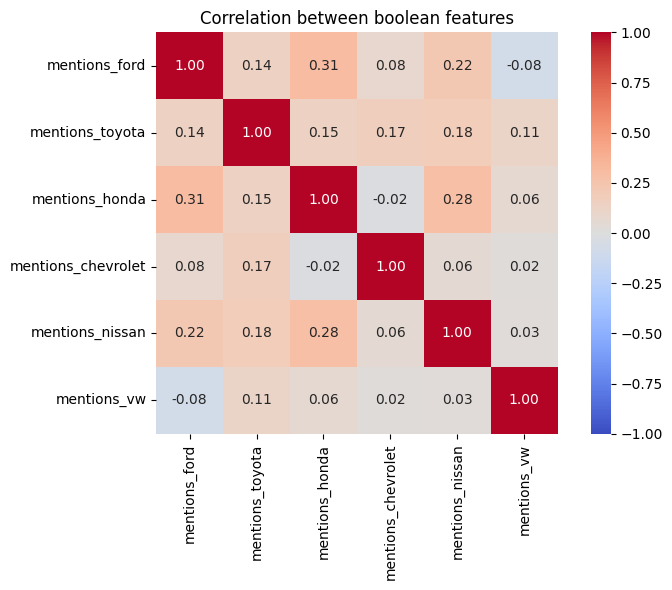

In [0]:
boolean_cols = ['mentions_ford','mentions_toyota','mentions_honda','mentions_chevrolet','mentions_nissan','mentions_vw']

assembler = VectorAssembler(inputCols=boolean_cols, outputCol="features_vec")
vector_df = assembler.transform(auto_post_features).select("features_vec")

corr_matrix = Correlation.corr(vector_df, "features_vec", method="pearson").head()[0]
corr_array = corr_matrix.toArray()

corr_df = pd.DataFrame(corr_array, index=boolean_cols, columns=boolean_cols)

plt.figure(figsize=(max(8, len(boolean_cols) * 0.5), max(6, len(boolean_cols) * 0.4)))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True)
plt.title("Correlation between boolean features")
plt.tight_layout()
plt.show()

In [0]:
# Write the DataFrame directly (SC-compatible approach)
(
    auto_post_features.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(AUTO_POST_FEATURES_TABLE)
)

# Add UC column comments via ALTER TABLE (SC-compatible approach)
column_comments = [
    ("article_id", "Unique identifier from the source dataset"),
    ("topic", "Newsgroup topic label (filtered to rec.autos for this table)"),
    ("subject", "Subject line of the original post"),
    ("organization", "Organization header, self-reported by the poster"),
    ("lines_header", "Original Lines: header value (not verified against actual line count)"),
    ("distribution", "Distribution header, where present"),
    ("text", "Article body: headers and footer stripped, person/email PII masked"),
    ("char_count", "Character count of the cleaned body text"),
    ("word_count", "Word count of the cleaned body text"),
    ("summary", "LLM-generated summary of the article body (ai_summarize / ai_query, ~30 words)"),
    ("embedding", "Raw embedding vector from the databricks-bge-large-en endpoint, generated from the summary"),
    ("features", "Embedding cast to MLlib Vector type, input to KMeans"),
    ("normalized_features", "L2-normalized embedding vector; KMeans was fit on this column, not raw features"),
    ("cluster", "KMeans cluster assignment (k=3, fit on normalized_features across all three newsgroups)"),
    ("distance_to_centroid", "Euclidean distance from this point to its assigned cluster's centroid, in normalized_features space"),
    ("tension_label", "LLM-classified tone of the post: escalating, de-escalating, or neutral"),
    ("tension_reasoning", "One-sentence LLM justification for the tension_label"),
    ("make_list", "LLM-extracted, LLM-normalized list of distinct car makes/models mentioned in the post (raw extraction canonicalized via a separate ai_query mapping pass)"),
    ("make_count", "Count of distinct entries in make_list"),
    ("mentions_ford", "True if make_list contains a Ford make or model"),
    ("mentions_toyota", "True if make_list contains a Toyota make or model"),
    ("mentions_honda", "True if make_list contains a Honda make or model"),
    ("mentions_chevrolet", "True if make_list contains a Chevrolet make or model"),
    ("mentions_nissan", "True if make_list contains a Nissan make or model"),
    ("mentions_vw", "True if make_list contains a Volkswagen make or model"),
]

for col_name, comment in column_comments:
    # Escape single quotes in comment for SQL
    escaped_comment = comment.replace("'", "''")
    spark.sql(f"ALTER TABLE {AUTO_POST_FEATURES_TABLE} ALTER COLUMN {col_name} COMMENT '{escaped_comment}'")

spark.sql(f"""
    COMMENT ON TABLE {AUTO_POST_FEATURES_TABLE} IS
    'rec.autos subset: cleaned, redacted, summarized, embedded, clustered, tone-classified, plus LLM-extracted and normalized car make/model mentions with per-make boolean flags for the six most common manufacturers found in this dataset.'
""")

spark.sql(f"""
    ALTER TABLE {AUTO_POST_FEATURES_TABLE} SET TBLPROPERTIES (
        'notebook_path' = '{NOTEBOOK_PATH}',
        'processed_by' = '{PROCESSED_BY}',
        'last_ingested_at' = '{datetime.now(UTC).isoformat()}'
    )
""")

DataFrame[]

In [0]:
%sql
-- Query the final rec.autos feature table with all extracted fields
SELECT 
  article_id,
  subject,
  summary,
  cluster,
  tension_label,
  make_list,
  make_count,
  mentions_ford,
  mentions_toyota,
  mentions_honda
FROM hackathon.default.tutorial_sci_med_auto_post_features_tutorial
LIMIT 10

article_id,subject,summary,cluster,tension_label,make_list,make_count,mentions_ford,mentions_toyota,mentions_honda
101551,Re: Saturn's Pricing Policy,"Debater argues that reducing dealer profit doesn't necessarily save buyers money, but others counter that lower profits can lead to lower prices, benefiting consumers.",1,neutral,List(Saturn),1,false,false,false
101552,Re: Are BMW's worth the price?,"BMW 325is performance numbers vary: 0-60mph in 7.4-8.3s, 1/4 mile in 15.3-16.2s.",2,neutral,List(BMW),1,false,false,false
101553,RE: headlights problem,"Truck's low beam headlight issue resolved, caused by loose wire connection, not a fuse problem.",1,de-escalating,null,0,false,false,false
101554,left turn signal won't stop automaticaly,"1984 Chev S10 Pickup's left turn signal won't stop after turning, possibly due to mechanical issue near steering wheel.",1,neutral,List(Chevrolet),1,false,false,false
101555,"Re: What is "" Volvo "" ?","Volvo cars are durable, lasting 18-20 years, with high mileage and minimal repairs, making them a reliable choice despite high dealer repair costs.",2,escalating,List(Volvo),1,false,false,false
101556,Re: saturn pricing blatherings,"Saturn has multiple dealerships in some cities, like Sacramento with two dealerships.",2,neutral,List(Saturn),1,false,false,false
101557,Radio for Toyota Tercel,Seeking replacement radio/tape player for 1984 Toyota Tercel with easy installation.,2,neutral,List(Toyota),1,false,true,false
101558,1993 Infiniti G20,"Considering Infiniti G20 due to high reliability ranking, but concerned about visibility and seeking feedback on the brand and a special deal offer.",2,neutral,"List(Infiniti, Mitsubishi, Honda, Toyota)",4,false,true,true
101559,Re: Basics about maintenance,"Car maintenance basics include changing oil and filter every 3000 miles, monthly tire checks, and regular fluid checks.",1,neutral,null,0,false,false,false
101560,Re: Integra GSR (really about other cars),The author prioritizes an Integra's moonroof with a sliding sunshade over other cars' handling and acceleration capabilities.,2,de-escalating,List(Acura),1,false,false,false


## Summary: What We've Built

This tutorial demonstrated a complete pipeline for engineering semantic features from unstructured text, grounded in the UK Government AI Principles:

**Stage 1 — Ingest & Protection (P2, P4, P7, P10)**
* Loaded and cleaned raw newsgroup data
* Redacted PII using `ai_mask` + regex hybrid approach
* Persisted to Unity Catalog with full metadata and provenance

**Stage 2 — Feature Engineering (P1, P6, P9)**
* Summarization with `ai_summarize` to distill core meaning
* Text embeddings for semantic similarity measurement
* Unsupervised clustering to discover thematic groups
* Structured extraction with `ai_query` (tension classification, entity extraction)
* Hybrid deterministic+LLM approach for car make/model detection

**Key Takeaways:**
* **Validate, don't trust** — LLMs are powerful but fallible; always test and monitor
* **Use the right tool** — combine deterministic methods (regex, gazetteers) with LLMs
* **Build human review in** — domain experts must validate semantic features before use
* **Monitor continuously** — track costs, quality, and drift over time

## Now it is your turn!

You've seen how to create semantic features from free text. The datasets provided for the hackathon offer many opportunities to apply these techniques:
* Extract entities from CQC inspection reports
* Classify sentiment in citizen feedback
* Cluster similar policy documents
* Detect themes in consultation responses

We look forward to seeing what you build!